# GeminiDecomp — Valutazione Performance DDETR

Valuta le performance di un modello Deformable DETR sul task di object detection del dataset piemmeci_test.
Le predizioni sono in formato COCO (`DDETR_on_testset.json`): lista di `{image_id, category_id, bbox, score}` con bbox in pixel `[x, y, w, h]`.

Poiché il modello è addestrato su una singola categoria (category_id=0), la valutazione è **class-agnostic** (classe "all").
Le metriche (Precision, Recall, F1) vengono calcolate al variare della soglia IoU da 0.1 a 0.95.

## 0. Setup

In [ ]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from config import (
    GROUND_TRUTH_PATH, DATA_DIR,
    IOU_THRESHOLDS, IOU_MAIN, RESULTS_DIR,
)
from src.data_loader import load_ground_truth, load_coco_predictions
from src.metrics import (
    compute_metrics_at_iou,
    compute_metrics_sweep,
    compute_map,
    collect_iou_scores,
)
from src.visualization import (
    plot_metrics_vs_iou,
    plot_summary_heatmap,
    plot_iou_histogram,
    plot_pr_curve,
)

DDETR_PREDS_PATH = DATA_DIR / "DDETR_predictions_on_testset.json"
RESULTS_DIR.mkdir(exist_ok=True)

SCORE_THRESHOLD = 0.5

print(f"Project root  : {project_root}")
print(f"Predizioni    : {DDETR_PREDS_PATH}")
print(f"Score thresh  : {SCORE_THRESHOLD}")

Project root  : /home/giorgiomelch/VS_Workspace/about_chart_to_table/GeminiDecomp
Predizioni    : /home/giorgiomelch/VS_Workspace/about_chart_to_table/GeminiDecomp/data/DDETR_on_testset.json
Score thresh  : 0.5


## 1. Caricamento dati

In [2]:
gt    = load_ground_truth(GROUND_TRUTH_PATH)
preds = load_coco_predictions(DDETR_PREDS_PATH, GROUND_TRUTH_PATH,
                               score_threshold=SCORE_THRESHOLD,
                               full_image_fallback=True)

n_gt_boxes   = sum(len(v) for v in gt.values())
n_pred_boxes = sum(len(v) for v in preds.values())

print(f"Immagini GT          : {len(gt)}")
print(f"Immagini predizioni  : {len(preds)}")
print(f"Bbox GT totali       : {n_gt_boxes}")
print(f"Bbox predizioni tot. : {n_pred_boxes}")
print()
print("Nota: il DDETR predice una sola categoria (class-agnostic).")
print("Immagini senza predizioni sopra soglia → bbox full-image [0,0,100,100] come fallback.")

Immagini GT          : 998
Immagini predizioni  : 998
Bbox GT totali       : 4597
Bbox predizioni tot. : 4648

Nota: il DDETR predice una sola categoria (class-agnostic).
Immagini senza predizioni sopra soglia → bbox full-image [0,0,100,100] come fallback.


### 1.1 Distribuzione score confidence

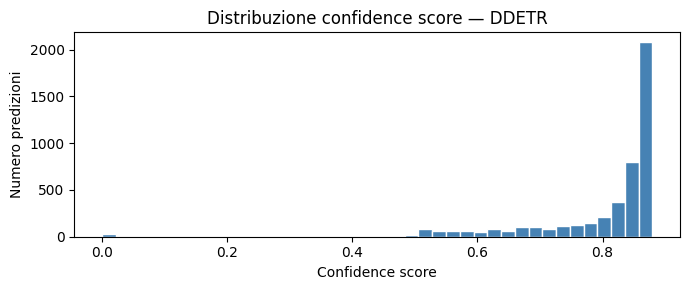

  score >= 0.0:  4648 predizioni
  score >= 0.1:  4615 predizioni
  score >= 0.3:  4615 predizioni
  score >= 0.5:  4615 predizioni
  score >= 0.7:  3950 predizioni


In [3]:
all_scores = [b["score"] for boxes in preds.values() for b in boxes]

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(all_scores, bins=40, color="steelblue", edgecolor="white")
ax.set_xlabel("Confidence score")
ax.set_ylabel("Numero predizioni")
ax.set_title("Distribuzione confidence score — DDETR")
plt.tight_layout()
plt.show()

import numpy as np
scores_arr = np.array(all_scores)
for thr in [0.0, 0.1, 0.3, 0.5, 0.7]:
    print(f"  score >= {thr:.1f}: {(scores_arr >= thr).sum():5d} predizioni")

## 2. Baseline — IoU = 0.5

In [4]:
# Valutazione class-agnostic: target_class=None confronta tutti i GT vs tutte le predizioni
m = compute_metrics_at_iou(gt, preds, IOU_MAIN, target_class=None)
baseline_df = pd.DataFrame([{"class": "all", **m}])
baseline_df = baseline_df[["class", "precision", "recall", "f1", "tp", "fp", "fn"]]
baseline_df[["precision", "recall", "f1"]] = baseline_df[["precision", "recall", "f1"]].round(4)

print(f"Metriche a IoU = {IOU_MAIN} (DDETR, class-agnostic):")
display(baseline_df)

Metriche a IoU = 0.5 (DDETR, class-agnostic):


,class,precision,recall,f1,tp,fp,fn
0,all,0.9271,0.9374,0.9322,4309,339,288


## 3. Sweep IoU — da 0.1 a 0.95

In [5]:
from tqdm.notebook import tqdm

rows = []
for thr in tqdm(IOU_THRESHOLDS, desc="IoU sweep"):
    m = compute_metrics_at_iou(gt, preds, thr, target_class=None)
    rows.append({"iou_threshold": thr, "class": "all", **m})

sweep_df = pd.DataFrame(rows)
sweep_df = sweep_df[["iou_threshold", "class", "precision", "recall", "f1", "tp", "fp", "fn"]]

print(f"Sweep completato: {len(sweep_df)} righe")
display(sweep_df.round(4))

IoU sweep:   0%|          | 0/11 [00:00<?, ?it/s]

Sweep completato: 11 righe


,iou_threshold,class,precision,recall,f1,tp,fp,fn
0,0.10,all,0.9501,0.9606,0.9553,4416,232,181
1,0.20,all,0.9456,0.9561,0.9508,4395,253,202
2,0.30,all,0.9374,0.9478,0.9426,4357,291,240
3,0.40,all,0.9324,0.9428,0.9376,4334,314,263
4,0.50,all,0.9271,0.9374,0.9322,4309,339,288
5,0.60,all,0.9167,0.9269,0.9218,4261,387,336
6,0.70,all,0.9021,0.9121,0.9071,4193,455,404
7,0.75,all,0.8802,0.8899,0.8850,4091,557,506
8,0.80,all,0.8343,0.8436,0.8389,3878,770,719
9,0.90,all,0.5385,0.5445,0.5415,2503,2145,2094


## 4. Grafici

### 4.1 Precision / Recall / F1 vs soglia IoU

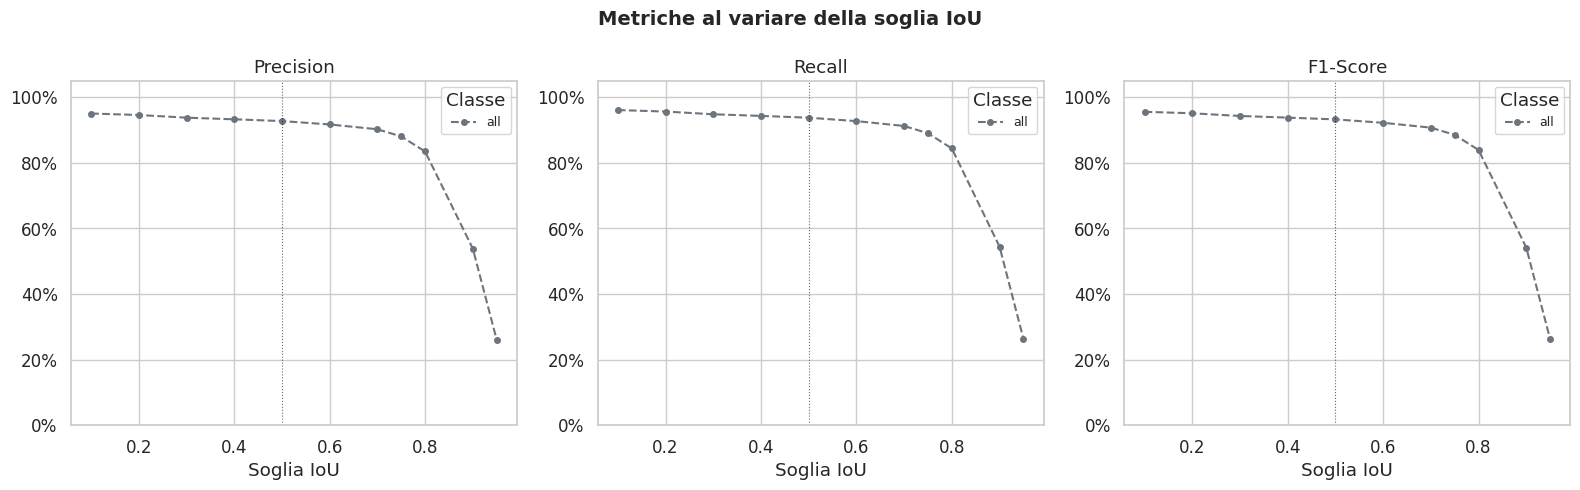

In [6]:
fig = plot_metrics_vs_iou(sweep_df)
plt.show()

### 4.2 Distribuzione IoU score dei match TP

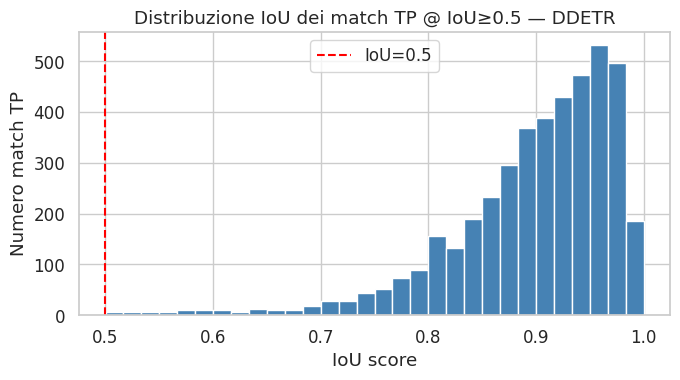

Totale TP matchati: 4309


In [7]:
iou_scores = collect_iou_scores(gt, preds, iou_threshold=IOU_MAIN)

# Aggrega tutte le classi (il loader assegna label='detection')
all_iou = [s for scores in iou_scores.values() for s in scores]
if not all_iou:
    # Calcolo manuale: label='detection' non è in iou_scores (chart/non_chart)
    from src.iou_matching import hungarian_match
    all_iou = []
    for fname in set(gt) | set(preds):
        g = [b["bbox"] for b in gt.get(fname, [])]
        p = [b["bbox"] for b in preds.get(fname, [])]
        _, _, _, matches = hungarian_match(p, g, IOU_MAIN)
        all_iou.extend(iou_val for _, _, iou_val in matches)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(all_iou, bins=30, color="steelblue", edgecolor="white")
ax.axvline(IOU_MAIN, color="red", linestyle="--", label=f"IoU={IOU_MAIN}")
ax.set_xlabel("IoU score")
ax.set_ylabel("Numero match TP")
ax.set_title(f"Distribuzione IoU dei match TP @ IoU≥{IOU_MAIN} — DDETR")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Totale TP matchati: {len(all_iou)}")

## 5. Riepilogo — mF1 medio

In [8]:
mf1 = float(sweep_df["f1"].mean())
print(f"mF1 @ IoU [{IOU_THRESHOLDS[0]}:{IOU_THRESHOLDS[-1]}] = {mf1:.4f}")
print()
row = baseline_df.iloc[0]
print(f"Metriche a IoU={IOU_MAIN} (class-agnostic):")
print(f"  P={row['precision']:.4f}  R={row['recall']:.4f}  F1={row['f1']:.4f}")

mF1 @ IoU [0.1:0.95] = 0.8250

Metriche a IoU=0.5 (class-agnostic):
  P=0.9271  R=0.9374  F1=0.9322


## 6. Analisi per soglia confidence

Mostra come variano le metriche a IoU=0.5 al variare della soglia di confidence.

,score_threshold,n_preds,precision,recall,f1,tp,fp,fn
0,0.0,4648,0.9271,0.9374,0.9322,4309,339,288
1,0.1,4615,0.9270,0.9306,0.9288,4278,337,319
2,0.2,4615,0.9270,0.9306,0.9288,4278,337,319
3,0.3,4615,0.9270,0.9306,0.9288,4278,337,319
4,0.4,4615,0.9270,0.9306,0.9288,4278,337,319
5,0.5,4615,0.9270,0.9306,0.9288,4278,337,319
6,0.6,4318,0.9453,0.8880,0.9158,4082,236,515
7,0.7,3950,0.9580,0.8231,0.8855,3784,166,813
8,0.8,3384,0.9681,0.7126,0.8209,3276,108,1321
9,0.9,0,0.0000,0.0000,0.0000,0,0,4597


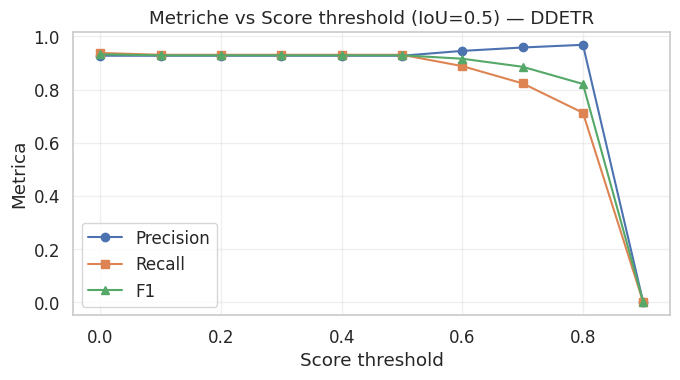

In [9]:
score_thresholds = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
score_rows = []

for thr in score_thresholds:
    preds_thr = {
        fname: [b for b in boxes if b["score"] >= thr]
        for fname, boxes in preds.items()
    }
    n = sum(len(v) for v in preds_thr.values())
    m = compute_metrics_at_iou(gt, preds_thr, IOU_MAIN, target_class=None)
    score_rows.append({"score_threshold": thr, "n_preds": n, **m})

score_df = pd.DataFrame(score_rows)
score_df[["precision", "recall", "f1"]] = score_df[["precision", "recall", "f1"]].round(4)
display(score_df[["score_threshold", "n_preds", "precision", "recall", "f1", "tp", "fp", "fn"]])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(score_df["score_threshold"], score_df["precision"], marker="o", label="Precision")
ax.plot(score_df["score_threshold"], score_df["recall"],    marker="s", label="Recall")
ax.plot(score_df["score_threshold"], score_df["f1"],        marker="^", label="F1")
ax.set_xlabel("Score threshold")
ax.set_ylabel("Metrica")
ax.set_title(f"Metriche vs Score threshold (IoU={IOU_MAIN}) — DDETR")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()